# Task 3 — Cuisine Classification

## Import Libraries

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, classification_report, confusion_matrix)

print("All libraries imported successfully!")

All libraries imported successfully!


## Load Dataset

In [6]:
df = pd.read_csv(r"C:\Users\My PC\Downloads\Dataset .csv", encoding='latin1')

print(f"Dataset Shape: {df.shape}")
print(f"\nColumns:\n{list(df.columns)}")
df.head()

Dataset Shape: (9551, 21)

Columns:
['ï»¿Restaurant ID', 'Restaurant Name', 'Country Code', 'City', 'Address', 'Locality', 'Locality Verbose', 'Longitude', 'Latitude', 'Cuisines', 'Average Cost for two', 'Currency', 'Has Table booking', 'Has Online delivery', 'Is delivering now', 'Switch to order menu', 'Price range', 'Aggregate rating', 'Rating color', 'Rating text', 'Votes']


,ï»¿Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,Botswana Pula(P),No,No,No,No,4,4.9,Dark Green,Excellent,365
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",...,Botswana Pula(P),Yes,No,No,No,4,4.8,Dark Green,Excellent,229


## Basic Info & Summary

In [9]:
print("=== Dataset Info ===")
df.info()

print("\n=== Statistical Summary ===")
df.describe()

=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9551 entries, 0 to 9550
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   ï»¿Restaurant ID      9551 non-null   int64  
 1   Restaurant Name       9551 non-null   object 
 2   Country Code          9551 non-null   int64  
 3   City                  9551 non-null   object 
 4   Address               9551 non-null   object 
 5   Locality              9551 non-null   object 
 6   Locality Verbose      9551 non-null   object 
 7   Longitude             9551 non-null   float64
 8   Latitude              9551 non-null   float64
 9   Cuisines              9542 non-null   object 
 10  Average Cost for two  9551 non-null   int64  
 11  Currency              9551 non-null   object 
 12  Has Table booking     9551 non-null   object 
 13  Has Online delivery   9551 non-null   object 
 14  Is delivering now     9551 non-null   object 
 15  

,ï»¿Restaurant ID,Country Code,Longitude,Latitude,Average Cost for two,Price range,Aggregate rating,Votes
count,9.551000e+03,9551.000000,9551.000000,9551.000000,9551.000000,9551.000000,9551.000000,9551.000000
mean,9.051128e+06,18.365616,64.126574,25.854381,1199.210763,1.804837,2.666370,156.909748
std,8.791521e+06,56.750546,41.467058,11.007935,16121.183073,0.905609,1.516378,430.169145
min,5.300000e+01,1.000000,-157.948486,-41.330428,0.000000,1.000000,0.000000,0.000000
25%,3.019625e+05,1.000000,77.081343,28.478713,250.000000,1.000000,2.500000,5.000000
50%,6.004089e+06,1.000000,77.191964,28.570469,400.000000,2.000000,3.200000,31.000000
75%,1.835229e+07,1.000000,77.282006,28.642758,700.000000,2.000000,3.700000,131.000000
max,1.850065e+07,216.000000,174.832089,55.976980,800000.000000,4.000000,4.900000,10934.000000


## Check Missing Values

In [12]:
print("=== Missing Values ===")
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Percentage (%)': round(missing_pct, 2)
})
print(missing_df[missing_df['Missing Count'] > 0])

=== Missing Values ===
          Missing Count  Percentage (%)
Cuisines              9            0.09


## Explore Cuisine Distribution

Total unique cuisines: 145

Top 20 Cuisines:
Cuisines
North Indian    3960
Chinese         2735
Fast Food       1986
Mughlai          995
Italian          764
Bakery           745
Continental      736
Cafe             703
Desserts         653
South Indian     636
Street Food      562
American         390
Pizza            381
Mithai           380
Burger           251
Thai             234
Asian            233
Beverages        229
Ice Cream        226
Mexican          181
Name: count, dtype: int64


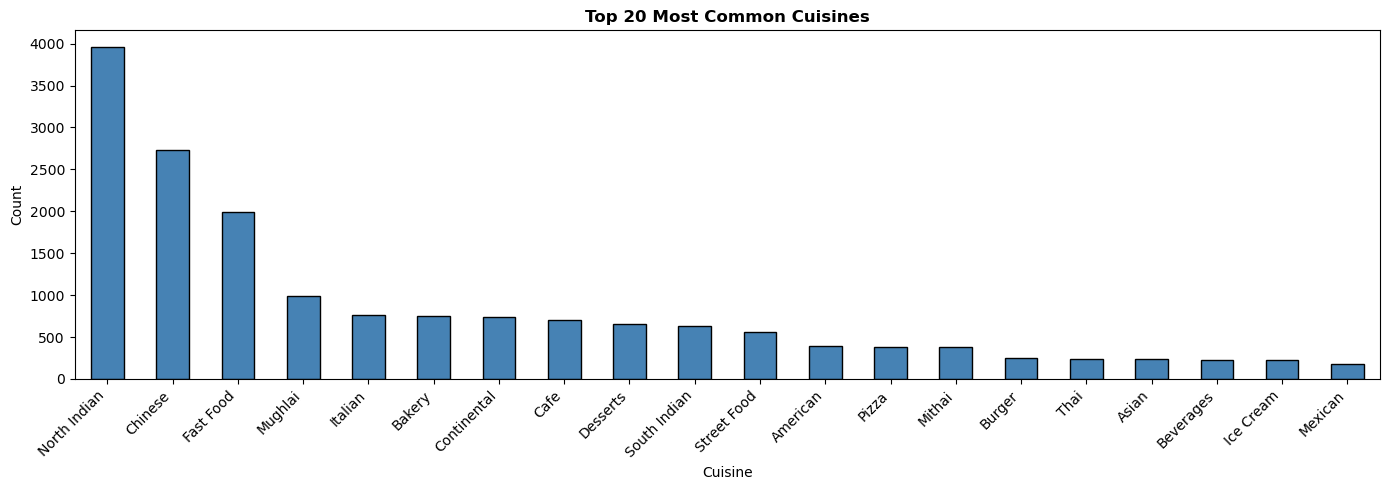

In [15]:
# Explore top cuisines
all_cuisines = df['Cuisines'].dropna().str.split(',').explode().str.strip()

print(f"Total unique cuisines: {all_cuisines.nunique()}")
print(f"\nTop 20 Cuisines:")
print(all_cuisines.value_counts().head(20))

plt.figure(figsize=(14, 5))
all_cuisines.value_counts().head(20).plot(
    kind='bar', color='steelblue', edgecolor='black'
)
plt.title('Top 20 Most Common Cuisines', fontweight='bold')
plt.xlabel('Cuisine')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Preprocessing: Clean & Prepare Target Variable

In [18]:
df_clean = df.copy()

# Fix BOM character in column names
df_clean.columns = df_clean.columns.str.replace('ï»¿', '', regex=False).str.strip()

# Remove unrated restaurants
df_clean = df_clean[df_clean['Aggregate rating'] > 0].copy()
print(f"Rated restaurants: {len(df_clean)}")

# Fill missing Cuisines
df_clean['Cuisines'].fillna('Unknown', inplace=True)

# Extract PRIMARY cuisine (first one listed)
df_clean['Primary Cuisine'] = df_clean['Cuisines'].str.split(',').str[0].str.strip()

print(f"\nTotal unique primary cuisines: {df_clean['Primary Cuisine'].nunique()}")
print(f"\nTop 15 Primary Cuisines:")
print(df_clean['Primary Cuisine'].value_counts().head(15))

Rated restaurants: 7403

Total unique primary cuisines: 119

Top 15 Primary Cuisines:
Primary Cuisine
North Indian    2208
Chinese          608
Cafe             549
Fast Food        479
Bakery           432
American         270
Continental      225
Italian          218
South Indian     203
Pizza            192
Street Food      160
Mithai           145
Mughlai          128
Ice Cream        127
Desserts         124
Name: count, dtype: int64


## Keep Top N Cuisines for Classification

Top 10 Cuisines selected:
['North Indian', 'Chinese', 'Cafe', 'Fast Food', 'Bakery', 'American', 'Continental', 'Italian', 'South Indian', 'Pizza']

Dataset size after filtering: (5384, 22)

Class distribution:
Primary Cuisine
North Indian    2208
Chinese          608
Cafe             549
Fast Food        479
Bakery           432
American         270
Continental      225
Italian          218
South Indian     203
Pizza            192
Name: count, dtype: int64


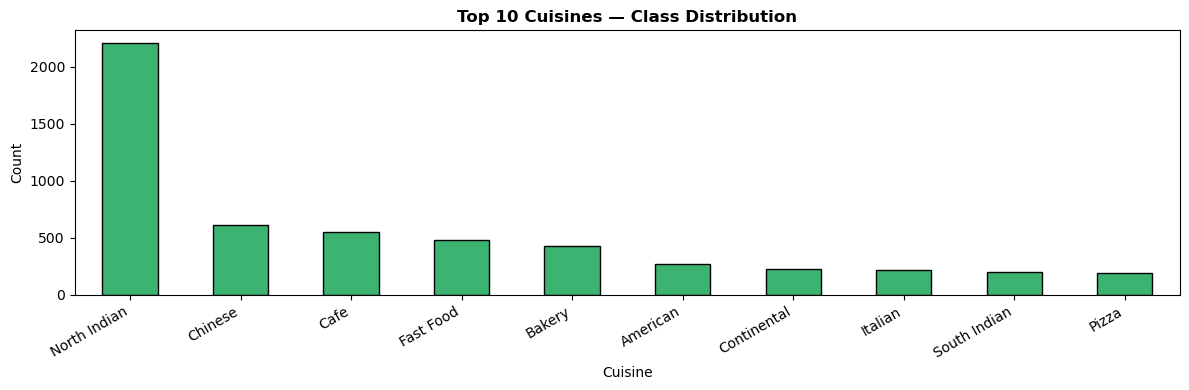

In [21]:
# Keep only Top 10 cuisines to avoid class imbalance
TOP_N = 10
top_cuisines = df_clean['Primary Cuisine'].value_counts().head(TOP_N).index.tolist()
print(f"Top {TOP_N} Cuisines selected:\n{top_cuisines}")

df_model = df_clean[df_clean['Primary Cuisine'].isin(top_cuisines)].copy()
print(f"\nDataset size after filtering: {df_model.shape}")
print(f"\nClass distribution:")
print(df_model['Primary Cuisine'].value_counts())

plt.figure(figsize=(12, 4))
df_model['Primary Cuisine'].value_counts().plot(
    kind='bar', color='mediumseagreen', edgecolor='black'
)
plt.title(f'Top {TOP_N} Cuisines — Class Distribution', fontweight='bold')
plt.xlabel('Cuisine')
plt.ylabel('Count')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()


## Feature Engineering & Encoding

In [24]:
# Select features
feature_cols = [
    'City', 'Average Cost for two', 'Currency',
    'Has Table booking', 'Has Online delivery',
    'Is delivering now', 'Price range',
    'Aggregate rating', 'Votes'
]

# Keep only existing columns
feature_cols = [col for col in feature_cols if col in df_model.columns]
print(f"Features used: {feature_cols}")

X = df_model[feature_cols].copy()
y = df_model['Primary Cuisine'].copy()

# Fill any remaining missing values
X['Average Cost for two'].fillna(X['Average Cost for two'].median(), inplace=True)

# Label encode categorical columns in X
le_feat = LabelEncoder()
for col in X.select_dtypes(include='object').columns:
    X[col] = le_feat.fit_transform(X[col].astype(str))
    print(f"Encoded: {col}")

# Encode target variable
le_target = LabelEncoder()
y_encoded = le_target.fit_transform(y)
print(f"\nTarget classes: {list(le_target.classes_)}")
print(f"Feature matrix shape: {X.shape}")

Features used: ['City', 'Average Cost for two', 'Currency', 'Has Table booking', 'Has Online delivery', 'Is delivering now', 'Price range', 'Aggregate rating', 'Votes']
Encoded: City
Encoded: Currency
Encoded: Has Table booking
Encoded: Has Online delivery
Encoded: Is delivering now

Target classes: ['American', 'Bakery', 'Cafe', 'Chinese', 'Continental', 'Fast Food', 'Italian', 'North Indian', 'Pizza', 'South Indian']
Feature matrix shape: (5384, 9)


## Train-Test Split & Scaling

In [27]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

print(f"Training set : {X_train.shape}")
print(f"Testing set  : {X_test.shape}")

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("Split and scaling done!")

Training set : (4307, 9)
Testing set  : (1077, 9)
Split and scaling done!


## Train All Classification Models

In [30]:
# Logistic Regression
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)
print("✔ Logistic Regression trained.")

# Decision Tree
dt = DecisionTreeClassifier(max_depth=10, random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)
print("✔ Decision Tree trained.")

# Random Forest
rf = RandomForestClassifier(n_estimators=100, max_depth=10,
                             random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
print("✔ Random Forest trained.")

# Gradient Boosting
gb = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1,
                                  random_state=42)
gb.fit(X_train, y_train)
y_pred_gb = gb.predict(X_test)
print("✔ Gradient Boosting trained.")

# KNN
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)
y_pred_knn = knn.predict(X_test_scaled)
print("✔ KNN Classifier trained.")

✔ Logistic Regression trained.
✔ Decision Tree trained.
✔ Random Forest trained.
✔ Gradient Boosting trained.
✔ KNN Classifier trained.


## Evaluate All Models

In [33]:
def evaluate_classifier(name, y_true, y_pred):
    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    rec  = recall_score(y_true, y_pred, average='weighted', zero_division=0)
    f1   = f1_score(y_true, y_pred, average='weighted', zero_division=0)
    return {
        'Model'    : name,
        'Accuracy' : round(acc,  4),
        'Precision': round(prec, 4),
        'Recall'   : round(rec,  4),
        'F1 Score' : round(f1,   4)
    }

results = [
    evaluate_classifier('Logistic Regression', y_test, y_pred_lr),
    evaluate_classifier('Decision Tree',        y_test, y_pred_dt),
    evaluate_classifier('Random Forest',        y_test, y_pred_rf),
    evaluate_classifier('Gradient Boosting',    y_test, y_pred_gb),
    evaluate_classifier('KNN',                  y_test, y_pred_knn),
]

results_df = pd.DataFrame(results).sort_values('Accuracy', ascending=False).reset_index(drop=True)
print("=== Model Comparison ===")
results_df

=== Model Comparison ===


,Model,Accuracy,Precision,Recall,F1 Score
0,Random Forest,0.4466,0.3791,0.4466,0.3535
1,Gradient Boosting,0.4345,0.3667,0.4345,0.3579
2,Logistic Regression,0.4318,0.2678,0.4318,0.3021
3,Decision Tree,0.4280,0.3683,0.4280,0.3757
4,KNN,0.3556,0.3128,0.3556,0.3258


## Metrics Bar Chart

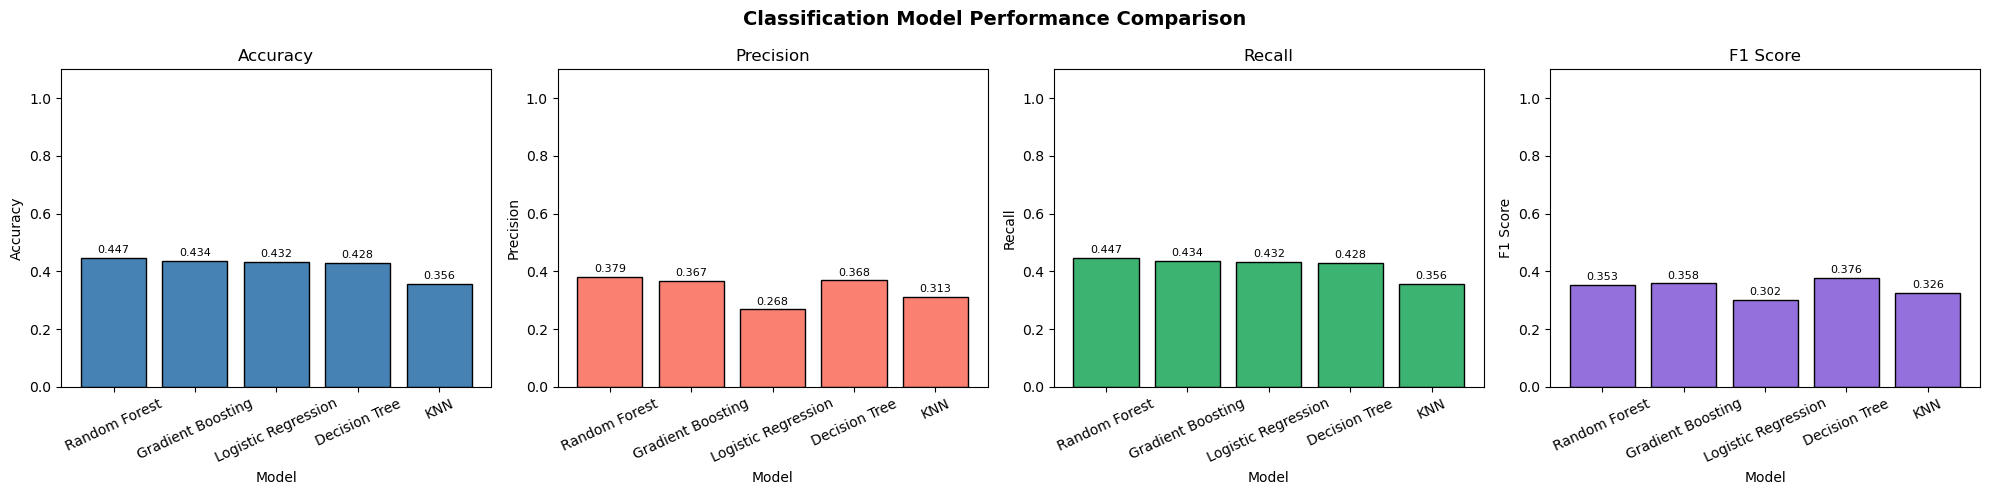

In [36]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
colors  = ['steelblue', 'salmon', 'mediumseagreen', 'mediumpurple']

for ax, metric, color in zip(axes, metrics, colors):
    bars = ax.bar(results_df['Model'], results_df[metric],
                  color=color, edgecolor='black')
    ax.set_title(f'{metric}')
    ax.set_xlabel('Model')
    ax.set_ylabel(metric)
    ax.set_ylim(0, 1.1)
    ax.tick_params(axis='x', rotation=25)
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.01,
                f'{bar.get_height():.3f}',
                ha='center', va='bottom', fontsize=8)

plt.suptitle('Classification Model Performance Comparison',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Confusion Matrix

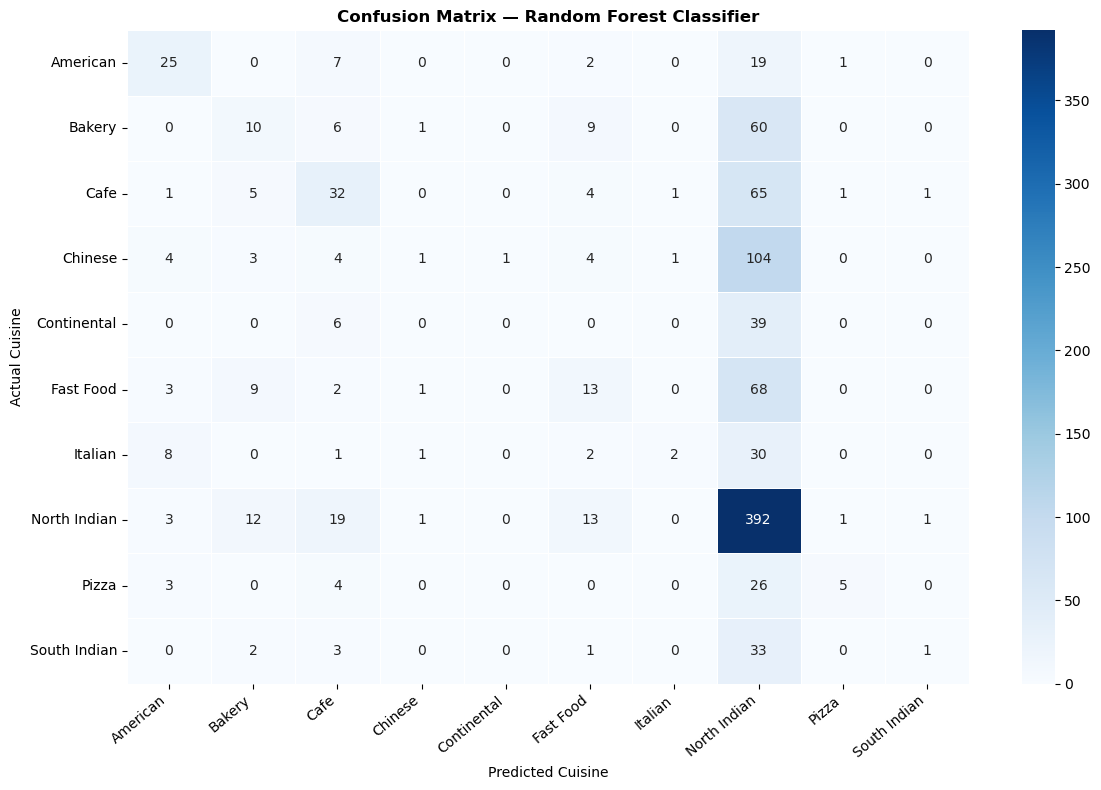

In [39]:
cm = confusion_matrix(y_test, y_pred_rf)
class_names = le_target.classes_

plt.figure(figsize=(12, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names,
            linewidths=0.5)
plt.title('Confusion Matrix — Random Forest Classifier', fontweight='bold')
plt.xlabel('Predicted Cuisine')
plt.ylabel('Actual Cuisine')
plt.xticks(rotation=40, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## Classification Report

In [42]:
print("=== Classification Report — Random Forest ===\n")
print(classification_report(
    y_test, y_pred_rf,
    target_names=le_target.classes_,
    zero_division=0
))

=== Classification Report — Random Forest ===

              precision    recall  f1-score   support

    American       0.53      0.46      0.50        54
      Bakery       0.24      0.12      0.16        86
        Cafe       0.38      0.29      0.33       110
     Chinese       0.20      0.01      0.02       122
 Continental       0.00      0.00      0.00        45
   Fast Food       0.27      0.14      0.18        96
     Italian       0.50      0.05      0.08        44
North Indian       0.47      0.89      0.61       442
       Pizza       0.62      0.13      0.22        38
South Indian       0.33      0.03      0.05        40

    accuracy                           0.45      1077
   macro avg       0.36      0.21      0.21      1077
weighted avg       0.38      0.45      0.35      1077



## Feature Importance Analysis

=== Feature Importances (Random Forest) ===
             Feature  Importance
Average Cost for two    0.254093
               Votes    0.217665
    Aggregate rating    0.205612
                City    0.107948
            Currency    0.077275
         Price range    0.068125
 Has Online delivery    0.042048
   Has Table booking    0.022161
   Is delivering now    0.005073


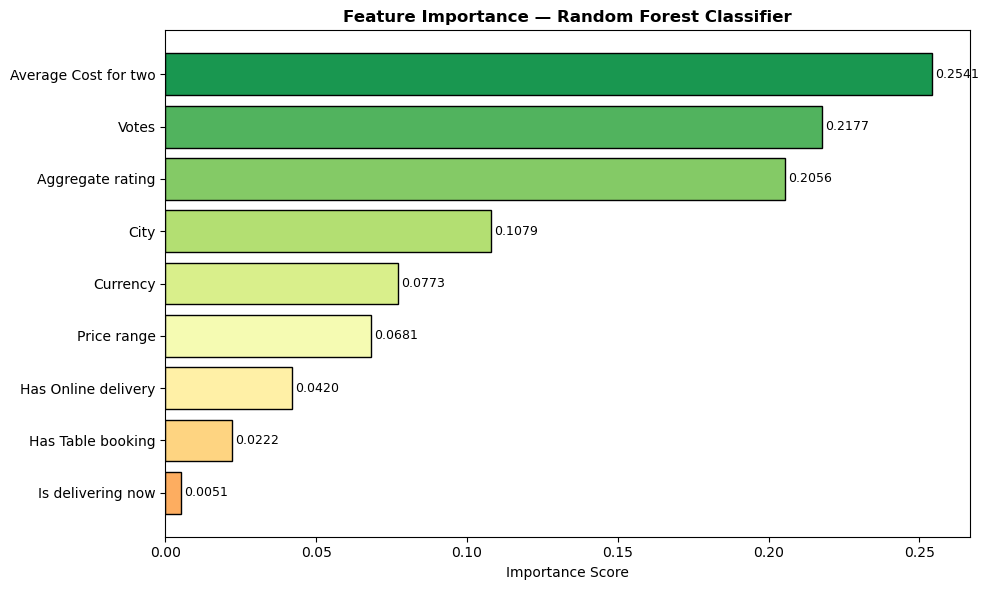

In [45]:
importances = rf.feature_importances_
feat_df = pd.DataFrame({
    'Feature'   : X.columns,
    'Importance': importances
}).sort_values('Importance', ascending=False).reset_index(drop=True)

print("=== Feature Importances (Random Forest) ===")
print(feat_df.to_string(index=False))

plt.figure(figsize=(10, 6))
colors_bar = plt.cm.RdYlGn(np.linspace(0.3, 0.9, len(feat_df)))
bars = plt.barh(feat_df['Feature'][::-1], feat_df['Importance'][::-1],
                color=colors_bar, edgecolor='black')

for bar, val in zip(bars, feat_df['Importance'][::-1]):
    plt.text(bar.get_width() + 0.001,
             bar.get_y() + bar.get_height()/2,
             f'{val:.4f}', va='center', fontsize=9)

plt.xlabel('Importance Score')
plt.title('Feature Importance — Random Forest Classifier', fontweight='bold')
plt.tight_layout()
plt.show()

## Per-Class Performance Analysis

=== Per-Cuisine Performance ===
              precision  recall  f1-score  support
North Indian      0.469   0.887     0.613    442.0
American          0.532   0.463     0.495     54.0
Cafe              0.381   0.291     0.330    110.0
Pizza             0.625   0.132     0.217     38.0
Fast Food         0.271   0.135     0.181     96.0
Bakery            0.244   0.116     0.157     86.0
Italian           0.500   0.045     0.083     44.0
South Indian      0.333   0.025     0.047     40.0
Chinese           0.200   0.008     0.016    122.0
Continental       0.000   0.000     0.000     45.0


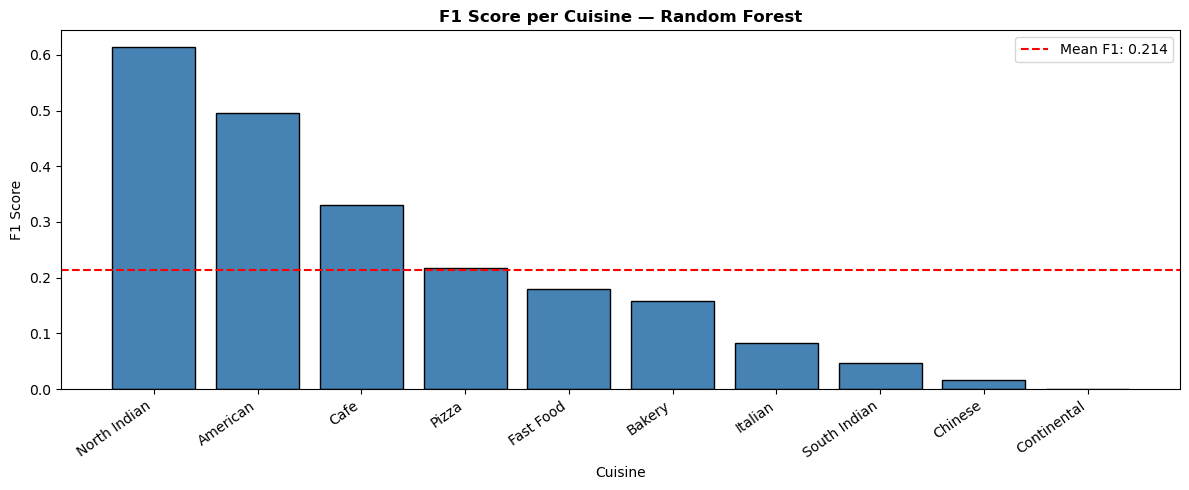

In [48]:
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                            # Per cuisine precision, recall, f1
report = classification_report(
    y_test, y_pred_rf,
    target_names=le_target.classes_,
    output_dict=True,
    zero_division=0
)

per_class_df = pd.DataFrame(report).T.iloc[:-3]  # exclude avg rows
per_class_df = per_class_df[['precision', 'recall', 'f1-score', 'support']]
per_class_df = per_class_df.sort_values('f1-score', ascending=False)

print("=== Per-Cuisine Performance ===")
print(per_class_df.round(3))

# Plot per-class F1
plt.figure(figsize=(12, 5))
bars = plt.bar(per_class_df.index, per_class_df['f1-score'],
               color='steelblue', edgecolor='black')
plt.axhline(y=per_class_df['f1-score'].mean(), color='red',
            linestyle='--', label=f"Mean F1: {per_class_df['f1-score'].mean():.3f}")
plt.title('F1 Score per Cuisine — Random Forest', fontweight='bold')
plt.xlabel('Cuisine')
plt.ylabel('F1 Score')
plt.xticks(rotation=35, ha='right')
plt.legend()
plt.tight_layout()
plt.show()                                                                                                                  

## Challenges & Bias Analysis

=== Class Imbalance Analysis ===



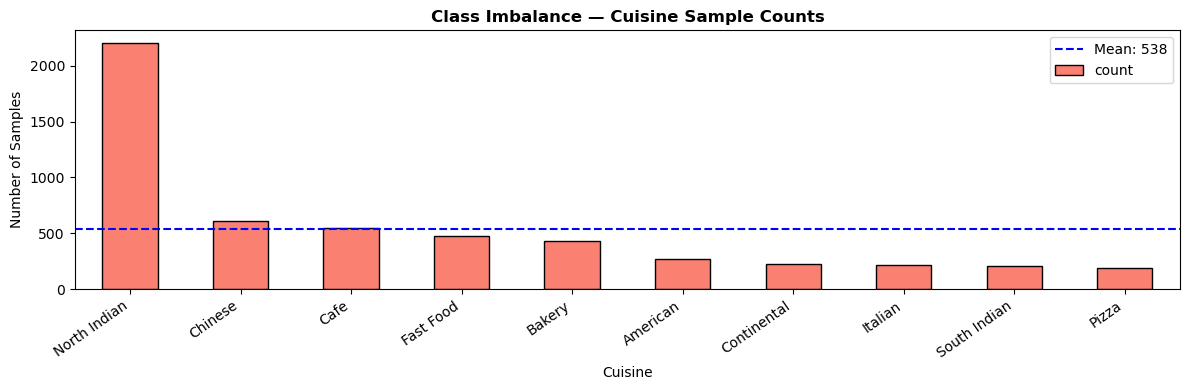


Observations:
  Most common cuisine  : North Indian  (2208 samples)
  Least common cuisine : Pizza  (192 samples)
  Imbalance ratio      : 11.5x

  → Classes with fewer samples tend to have lower recall.
  → Majority class dominates predictions (bias toward common cuisines).


In [51]:
print("=== Class Imbalance Analysis ===\n")
class_counts = df_model['Primary Cuisine'].value_counts()

plt.figure(figsize=(12, 4))
class_counts.plot(kind='bar', color='salmon', edgecolor='black')
plt.title('Class Imbalance — Cuisine Sample Counts', fontweight='bold')
plt.xlabel('Cuisine')
plt.ylabel('Number of Samples')
plt.xticks(rotation=35, ha='right')
plt.axhline(y=class_counts.mean(), color='blue',
            linestyle='--', label=f'Mean: {class_counts.mean():.0f}')
plt.legend()
plt.tight_layout()
plt.show()

print("\nObservations:")
print(f"  Most common cuisine  : {class_counts.index[0]}  ({class_counts.iloc[0]} samples)")
print(f"  Least common cuisine : {class_counts.index[-1]}  ({class_counts.iloc[-1]} samples)")
print(f"  Imbalance ratio      : {class_counts.iloc[0] / class_counts.iloc[-1]:.1f}x")
print(f"\n  → Classes with fewer samples tend to have lower recall.")
print(f"  → Majority class dominates predictions (bias toward common cuisines).")

## Predict on Custom Input

In [54]:
def predict_cuisine(input_data, scaler, model, le_target, feature_cols):
    """
    Predict cuisine for a new restaurant.
    input_data: dict with feature values
    """
    input_df = pd.DataFrame([input_data])

    # Encode categorical
    le_temp = LabelEncoder()
    for col in input_df.select_dtypes(include='object').columns:
        input_df[col] = le_temp.fit_transform(input_df[col].astype(str))

    # Ensure all feature columns exist
    for col in feature_cols:
        if col not in input_df.columns:
            input_df[col] = 0

    input_df = input_df[feature_cols]
    pred = model.predict(input_df)
    cuisine = le_target.inverse_transform(pred)[0]
    return cuisine


# Sample input — a new restaurant
new_restaurant = {
    'City'                 : 'New Delhi',
    'Average Cost for two' : 500,
    'Currency'             : 'Indian Rupees(Rs.)',
    'Has Table booking'    : 'Yes',
    'Has Online delivery'  : 'No',
    'Is delivering now'    : 'No',
    'Price range'          : 2,
    'Aggregate rating'     : 4.1,
    'Votes'                : 250
}

predicted = predict_cuisine(new_restaurant, scaler, rf, le_target, list(X.columns))
print(f"Predicted Cuisine for the new restaurant: 👉 {predicted}")

Predicted Cuisine for the new restaurant: 👉 American


In [56]:
best_row = results_df.iloc[0]

print("=" * 55)
print("     TASK 3: CUISINE CLASSIFICATION SUMMARY")
print("=" * 55)
print(f"  Dataset Size         : {df_model.shape[0]} restaurants")
print(f"  Number of Classes    : {TOP_N} cuisines")
print(f"  Features Used        : {len(feature_cols)}")
print(f"  Models Trained       : 5")
print("=" * 55)
print(f"  Best Model           : {best_row['Model']}")
print(f"  Accuracy             : {best_row['Accuracy']}")
print(f"  Precision            : {best_row['Precision']}")
print(f"  Recall               : {best_row['Recall']}")
print(f"  F1 Score             : {best_row['F1 Score']}")
print("=" * 55)
print(f"  Top Feature          : {feat_df.iloc[0]['Feature']}  ({feat_df.iloc[0]['Importance']:.4f})")
print(f"  2nd Feature          : {feat_df.iloc[1]['Feature']}  ({feat_df.iloc[1]['Importance']:.4f})")
print("=" * 55)
print("\n  Challenges Identified:")
print("  - Class imbalance: some cuisines have far fewer samples")
print("  - Similar features across cuisines reduce separability")
print("  - Multi-label cuisines simplified to primary cuisine only")
print("  - Bias toward majority classes (North Indian, Chinese)")
print("=" * 55)

     TASK 3: CUISINE CLASSIFICATION SUMMARY
  Dataset Size         : 5384 restaurants
  Number of Classes    : 10 cuisines
  Features Used        : 9
  Models Trained       : 5
  Best Model           : Random Forest
  Accuracy             : 0.4466
  Precision            : 0.3791
  Recall               : 0.4466
  F1 Score             : 0.3535
  Top Feature          : Average Cost for two  (0.2541)
  2nd Feature          : Votes  (0.2177)

  Challenges Identified:
  - Class imbalance: some cuisines have far fewer samples
  - Similar features across cuisines reduce separability
  - Multi-label cuisines simplified to primary cuisine only
  - Bias toward majority classes (North Indian, Chinese)
